In [2]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib, pickle
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')
from IPython.display import clear_output

from python import forces, integrators, random_matrix, simulate, densities, plotters
importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities); importlib.reload(plotters);

---

#### Quick look at MALA.

In this version Euler-Maruyama is being used as the proposal. Eigenvalues cross very frequently for $dt > 1/N^2$, so it's likely $dt$ will need to scale $\sim \mathcal{O}(N^2)$ for reasonable results.

- Fix $N \in \{30, 70, 100\}$.
- For each $N$, try $dt \in \{\mathcal{O}(1)$, $~1/N$, $~1/N^2\}$.

Expect heavy rejects for $dt \neq \frac{1}{N^2}$. 

In [ ]:
N = 30;
dt_str = ["1/N", "1/NrootN", "1/N^7/4", "1/N^2"]
dt_range = [1/N, 1/(N**(3/2)), 1/(N**(7/4)), 1/(N**2)]
beta = 2.0; T = 5.0; M = 50; potential_name = "quartic"

config = {"track_accepts": True, "burn_in": 0}
new_obs_results = {}

for dt, dt_name in zip(dt_range, dt_str):
    burn_steps = int(3.0/dt); total_steps = int(T/dt);
    config["burn_in"] = burn_steps
    init = random_matrix.init_gue_eigenvalues(M, N)
    
    mala_pipe = simulate.make_mala_pipeline(N, dt, potential_name, beta)
    traj = simulate.simulate_dbm(init, total_steps, mala_pipe)
    all_info = simulate.analyse_trajectory(traj, total_steps, **config)

    new_obs_results[(dt_name)] = all_info

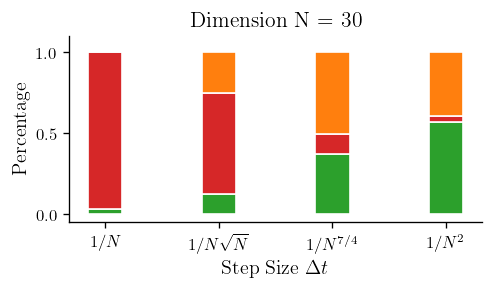

In [ ]:
dt_str_list = ["1/N", "1/NrootN", "1/N^7/4", "1/N^2"]
fig, ax = plt.subplots(figsize = (4, 2.3))

acceptances = [new_obs_results[(dt_str)]["accepts"].mean() for dt_str in dt_str_list]
cross_rejects = [new_obs_results[(dt_str)]["cross_rejects"].mean() for dt_str in dt_str_list]
other_rejects = [1 - acceptances[j] - cross_rejects[j] for j in range(len(acceptances))]

dt_str_list = [r"$1/N$", r"$1/N\sqrt{N}$", "$1/N^{7/4}$", "$1/N^2$"]
p1 = ax.bar(dt_str_list, acceptances, label = "Acceptances", color = '#2ca02c', edgecolor = 'white', width = 0.3)
p2 = ax.bar(dt_str_list, cross_rejects, bottom = acceptances, label = 'Rejects (Crossing)', color = '#d62728', edgecolor = 'white', width = 0.3)
p3 = ax.bar(dt_str_list, other_rejects, bottom = np.array(acceptances) + np.array(cross_rejects), label = 'Rejects (Other)', color = '#ff7f0e', edgecolor = 'white', width = 0.3)

ax.grid(False)
ax.set_ylim(-0.05, 1.1)

ax.set_ylabel("Percentage")
ax.set_xlabel("Step Size $\Delta t$")
ax.set_title(f"Dimension N = {N}")
ax.set_yticks([0, 0.5, 1])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig(f"figures/mala-cross-rejects-N{N}.pdf", format = "pdf", dpi = 120)

plt.show()

---
---
---

Adapative dt starts here - for MAIMLA dramatically lower number of steps.

---

In [36]:
M = 100; beta = 2.0; pot_name = "quartic";
total_steps = 20000; target = 0.3;
N_range = [50]
method = "mala"

last_accepts = np.zeros_like(N_range, dtype = float)
last_dts = np.zeros_like(N_range, dtype = float)
acc_histories = np.zeros_like(N_range, dtype = np.ndarray)
dt_histories = np.zeros_like(N_range, dtype = np.ndarray)

for j, N in enumerate(N_range):
    clear_output(wait = True)
    print(f"Running for N = {N}")

    init = random_matrix.init_quartic_eigenvalues(M, N, dt = 0.05)
    dt_init = 1/(N**(1.5)) # Start near best guess..
    burn_steps = 0 # Since now running from equilibrium.
    print(f"({burn_steps} burn-in steps)")

    accept_history, dt_history = simulate.target_dt(method, init, burn_steps, total_steps, pot_name, beta, dt_init, target)
    acc_histories[j] = accept_history; dt_histories[j] = dt_history
    
    last_accepts[j] = accept_history[-50:].mean()
    last_dts[j] = dt_history[-50:].mean()

Running for N = 50
(0 burn-in steps)


In [ ]:
# Quick check on last accepts.
print(f"Accepts ", last_accepts)
print(last_dts)

fig, ax = plt.subplots()
ax.loglog(N_range, last_dts, label = "final dt", marker = 'o')

log_N = np.log10(N_range); log_dt = np.log10(last_dts);
slope, intercept = np.polyfit(log_N, log_dt, 1)
ax.plot(N_range, 10**(intercept)*N_range**slope, linestyle = "--", alpha = 0.5, label = f"slope {slope:.2f}")
ax.set_title(method.upper())

ax.legend()
plt.show()

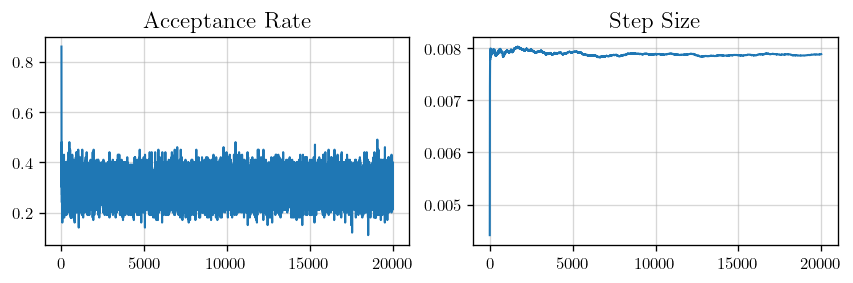

In [ ]:
# Trace plots for these Ns.
for j, N in enumerate(N_range):
    fig, axes = plt.subplots(1, 2, figsize = (7, 2.25))
    axes[0].plot(acc_histories[j])
    axes[1].plot(dt_histories[j])

    ax1, ax2 = axes
    ax1.set_title("Acceptance Rate", fontsize = 14)
    ax2.set_title("Step Size", fontsize = 14)

    # plt.savefig("example-adapative-trace.pdf", format = "pdf", dpi = 120)
    plt.show()

In [5]:
# Save the results.
import pickle

data = {}
for j, N in enumerate(N_range):
    key = (N, method) # (N, "hmc") for instance.

    data[key] = {
        "N": N, "M": M, "pot_name": pot_name,
        "burn_steps": int(0.5/(1/N)), "total_steps": total_steps,
        "num_last_avg": 50, # Hard coded in loop.
        "last_accepts": last_accepts[j], "last_dts": last_dts[j],
        "all_accepts": acc_histories[j], "all_dts": dt_histories[j]
    }

filename = f"data/target{target}-{method}-N{','.join(map(str, N_range))}.pkl"
with open(filename, 'wb') as f:
    pickle.dump(data, f)

print(f"Data saved to {filename}.")

Data saved to data/target0.3-maimla-N250,300,350,400.pkl.


---
---
---

Reload and look at all results together.

---

In [51]:
hmc_paths = [f"data/adaptive_dt/hmc-N{N_range}.pkl" for N_range in ["50,70,100", "150"]]
mala_paths = [f"data/adaptive_dt/mala-N{N_range}.pkl" for N_range in ["50,70,100", "150,200"]]
maimla_paths = [f"data/adaptive_dt/maimla-N{N_range}.pkl" for N_range in ["50,70,100", "150,200"]]

maimla_paths_target03 = [f"data/adaptive_dt/target0.3-maimla-N{N_range}.pkl" for N_range in 
                         ["50,70,100,150,200", "250,300,350,400", "450,500,550,600"]]
mala_paths_target03 = [f"data/adaptive_dt/target0.3-mala-N{N_range}.pkl" for N_range in 
                       ["50,70,100,150,200", "250,300", "450,500,550,600", "800,1000"]]
maila_paths_target03 = [f"data/adaptive_dt/target0.3-maila-N{N_range}.pkl" for N_range in 
                       ["50,70,100", "150,200", "250,300"]]
hmc_paths_target03 = [f"data/adaptive_dt/target0.3-hmc-N{N_range}.pkl" for N_range in 
                       ["50,70,100,150", "200", "250"]]


def combine_dicts(file_paths):
    data = {}
    for path in file_paths:
        with open(path, "rb") as file:
            new_dict = pickle.load(file)
            data.update(new_dict)

    return data 
        
hmc_data = combine_dicts(hmc_paths)
mala_data = combine_dicts(mala_paths)
maimla_data = combine_dicts(maimla_paths)

maimla_data_target03 = combine_dicts(maimla_paths_target03)
mala_data_target03 = combine_dicts(mala_paths_target03)
maila_data_target03 = combine_dicts(maila_paths_target03)
hmc_data_target03 = combine_dicts(hmc_paths_target03)

data_target06 = {**hmc_data, **mala_data, **maimla_data}
data_target03 = {**mala_data_target03, **maimla_data_target03, **maila_data_target03, **hmc_data_target03}
data_target06.keys(), data_target03.keys()

(dict_keys([(50, 'hmc'), (70, 'hmc'), (100, 'hmc'), (150, 'hmc'), (50, 'mala'), (70, 'mala'), (100, 'mala'), (150, 'mala'), (200, 'mala'), (50, 'maimla'), (70, 'maimla'), (100, 'maimla'), (150, 'maimla'), (200, 'maimla')]),
 dict_keys([(50, 'mala'), (70, 'mala'), (100, 'mala'), (150, 'mala'), (200, 'mala'), (250, 'mala'), (300, 'mala'), (450, 'mala'), (500, 'mala'), (550, 'mala'), (600, 'mala'), (800, 'mala'), (1000, 'mala'), (50, 'maimla'), (70, 'maimla'), (100, 'maimla'), (150, 'maimla'), (200, 'maimla'), (250, 'maimla'), (300, 'maimla'), (350, 'maimla'), (400, 'maimla'), (450, 'maimla'), (500, 'maimla'), (550, 'maimla'), (600, 'maimla'), (50, 'maila'), (70, 'maila'), (100, 'maila'), (150, 'maila'), (200, 'maila'), (250, 'maila'), (300, 'maila'), (50, 'hmc'), (70, 'hmc'), (100, 'hmc'), (150, 'hmc'), (200, 'hmc'), (250, 'hmc')]))

HMC: (0.6) [50, 70, 100, 150]
MALA: (0.6) [50, 70, 100, 150, 200]
MAIMLA: (0.6) [50, 70, 100, 150, 200]
MALA: (0.3) [50, 70, 100, 150, 200, 250, 300, 450, 500, 550, 600, 800, 1000]
MAIMLA: (0.3) [50, 70, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600]
MAILA: (0.3) [50, 70, 100, 150, 200, 250, 300]
HMC: (0.3) [50, 70, 100, 150, 200, 250]


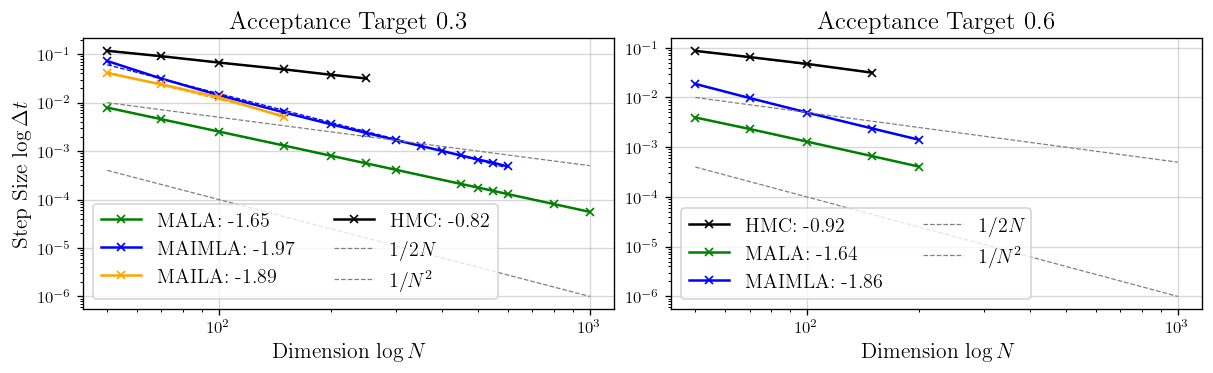

(dict_keys([('hmc', 0.6), ('mala', 0.6), ('maimla', 0.6), ('mala', 0.3), ('maimla', 0.3), ('maila', 0.3), ('hmc', 0.3)]),
 dict_keys([('hmc', 0.6), ('mala', 0.6), ('maimla', 0.6), ('mala', 0.3), ('maimla', 0.3), ('maila', 0.3), ('hmc', 0.3)]))

In [53]:
methods = ["hmc", "mala", "maimla", "mala_target03", "maimla_target03", "maila_target03", "hmc_target03"]
colours = {"mala": "green", "maimla": "blue", "maila": "orange", "hmc": "black"}
best_fits = {}; scheme_dts = {}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 3))

for method in methods:
    scheme = method if ("target" not in method) else method.split("_")[0]
    data = data_target06 if ("target" not in method) else data_target03 
    target = 0.6 if ("target" not in method) else 0.3
    ax = ax1 if target == 0.3 else ax2

    N_scheme = [N for (N, sch) in data if sch == scheme]
    print(f"{scheme.upper()}: ({target})", N_scheme)

    if (scheme == "maila"):
        N_scheme = N_scheme[0:4]

    last_dts = np.zeros_like(N_scheme, dtype = float)
    for j, N in enumerate(N_scheme):
        last_dts[j] = data[(N, scheme)]["last_dts"]

    scheme_dts[(scheme, target)] = (N_scheme, last_dts)
    
    # Find slope and intercept in log space.    
    log_N = np.log10(N_scheme); log_dts = np.log10(last_dts);
    slope, intercept = np.polyfit(log_N, log_dts, 1)
    best_fits[(scheme, target)] = (slope, intercept)

    # Plotter!
    colour = colours[scheme]
    ax.loglog(N_scheme, last_dts, label = f"{scheme.upper()}: {slope:.2f}", marker = 'x', markersize = 5, lw = 1.5, color = colour)
    ax.plot(N_scheme, 10**(intercept)*N_scheme**slope, ls = "--", lw = 0.75, color = colour)

test_range = np.logspace(np.log10(50), np.log10(1000), 5)
for ax in [ax1, ax2]:
    ax.plot(test_range, [1/(2*N) for N in test_range], label = r"$1/2N$", color = "grey", lw = 0.75, ls = "--")
    ax.plot(test_range, [1/(N**2) for N in test_range], label = r"$1/N^2$", color = "grey", lw = 0.75, ls = "--")
    ax.set_xlabel(r"Dimension $\log N$", fontsize = 13)

ax1.legend(fontsize = 12, ncols = 2); ax2.legend(fontsize = 12, ncols = 2);
ax1.set_title("Acceptance Target 0.3", fontsize = 15); ax2.set_title("Acceptance Target 0.6", fontsize = 15)
ax1.set_ylabel(r"Step Size $\log \Delta t$", fontsize = 13)

# plt.savefig("adapative-dt-TEMP.pdf", format = "pdf", dpi = 120)
plt.show()
best_fits.keys(), scheme_dts.keys()

---

Extrapolate the fits and see for larger $N$, e.g. $N = 1000, 2000$.

In [21]:
# Target acceptance 0.3.
large_N = 1000; M = 100; potential_type = "quartic"; beta = 2.0;
mala_slope, mala_c = best_fits[("mala", 0.3)]
maimla_slope, maimla_c = best_fits[("maimla", 0.3)]

mala_dt = 10**(mala_c)*large_N**(mala_slope)
maimla_dt = 10**(maimla_c)*large_N**(maimla_slope)
print(f"MALA {mala_dt}, MAIMLA {maimla_dt}, ratio {maimla_dt/mala_dt}.")

init = random_matrix.init_gue_eigenvalues(M, N)
print(f"Init finished.")

mala_pipe = simulate.make_mala_pipeline(N, mala_dt, potential_type, beta)
# maimla_pipe = simulate.make_maimla_pipeline(N, maimla_dt, potential_type, beta)

T = 0.25
total_steps = 1000 # Overwrite later.
mala_traj = simulate.simulate_dbm(init, total_steps, mala_pipe)
# maimla_traj = simulate.simulate_dbm(init, total_steps, maimla_pipe)

config = {"burn_in": 0, "track_accepts": True}
mala_info = simulate.analyse_trajectory(mala_traj, total_steps, **config)
# maimla_info = simulate.analyse_trajectory(maimla_traj, total_steps, **config)

print(mala_info["accepts"].mean())
#, mamla_info["accepts"].mean()

MALA 5.593239759524244e-05, MAIMLA 0.0001449313622089198, ratio 2.5911880849042586.
Init finished.
0.89465


---
---
---

Compare MAIMLA vs MALA on the same plot, including for different target.

---

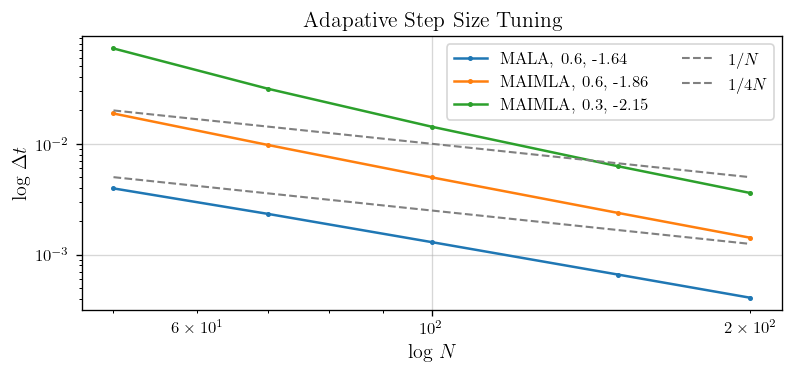

In [ ]:
N_range = [50, 70, 100, 150, 200] # For MALA and HMC
methods = ["mala", "maimla", "maimla_target03", "mala_target03"]

fig, ax = plt.subplots()

for j, method in enumerate(methods):
    dts = np.zeros_like(N_range, dtype = float)

    if ("target" in method):
        target = 0.3
        dict = data_target03
        method = method.split("_")[0]
    else:
        target = 0.6
        dict = data 
    for jj, N in enumerate(N_range):
        key = (N, method)
        # print(f"On key {key}.")
        dts[jj] = dict[key]["last_dts"]

    log_N = np.log10(N_range); log_dts = np.log10(dts);
    slope, intercept = np.polyfit(log_N, log_dts, 1)
    ax.loglog(N_range, dts, label = f"{method.upper()}, {target}, {slope:.2f}", marker = "o", lw = 1.5)

ax.plot(N_range, [1/(N) for N in N_range], linestyle = "--", alpha = 1, color = "gray", label = r"$1/N$")
ax.plot(N_range, [1/(4*N) for N in N_range], linestyle = "--", alpha = 1, color = "gray", label = r"$1/4N$")
# ax.plot(N_range, [1/(N**2) for N in N_range], linestyle = "--", alpha = 1, color = "gray", label = r"$1/N^2$")
ax.set_xlabel(r"log $N$")
ax.set_ylabel(r"log $\Delta t$")
ax.set_title("Adapative Step Size Tuning")

ax.legend(ncol = 2)
plt.show()


---
---
---
---
---

(Older) Using the linear fit see how they behave for larger $N$, e.g. $N = 300, 500$.

---

hmc 0.014696998291425808


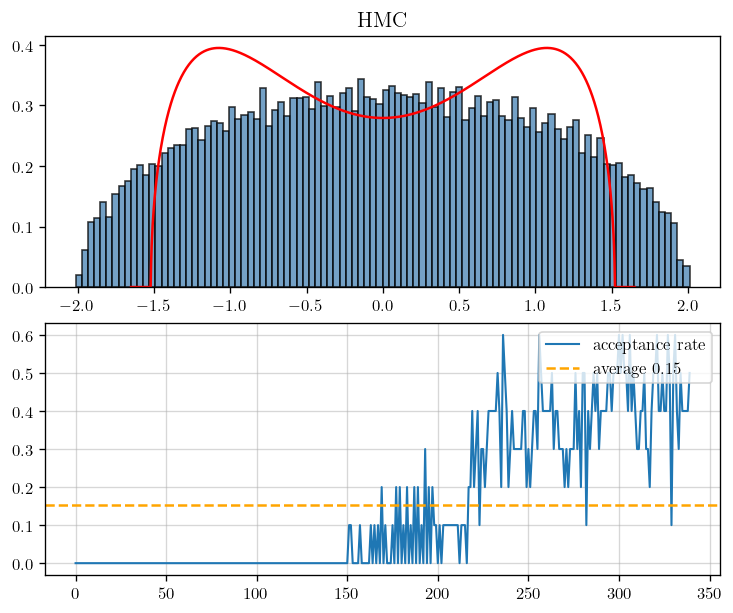

mala 0.00016457417262242532


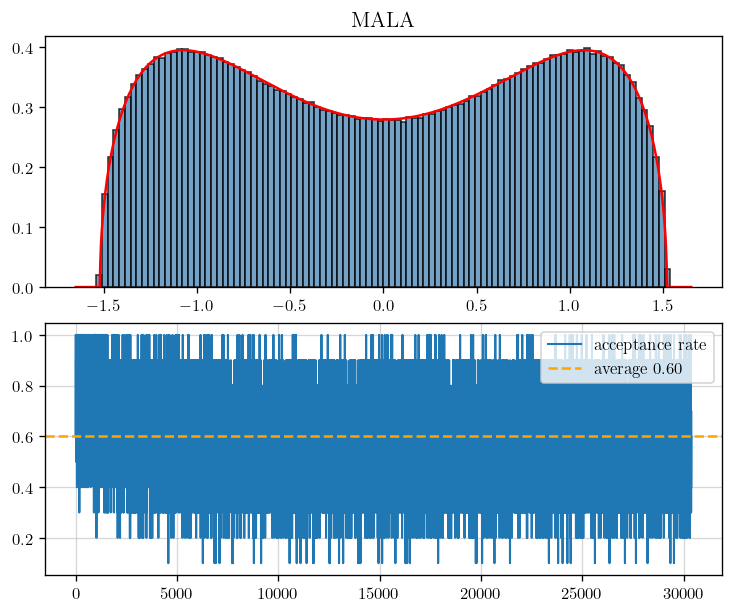

maimla 0.0004520514489301966


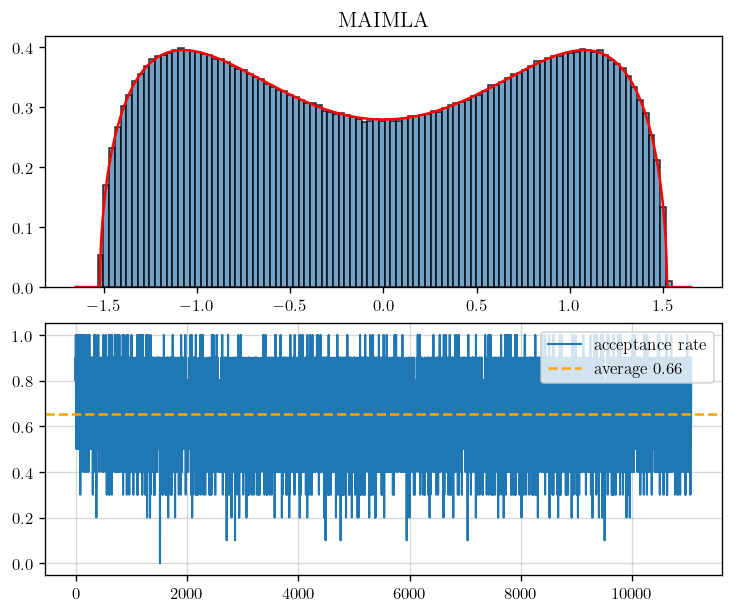

In [5]:
# print(extrap_N_range[7])
# = 349.65, so index = 7.
N = 350; 
M = 10; beta = 2.0; T = 5.0; pot_name = "quartic";

for j, method in enumerate(methods):
    init = random_matrix.init_gue_eigenvalues(M, N)
    dt = extrapolated_dts[j][7]
    total_steps = int(T/dt)
    print(method, dt)

    if (method == "maimla"):
        pipe = simulate.get_pipeline(
            "imla", N = N, dt = dt, potential_type = pot_name, beta = beta,
            metropolise = True)
    else:
        pipe = simulate.get_pipeline(
            method, N = N, dt = dt, potential_type = pot_name, beta = beta)
    
    trajectory = simulate.simulate_dbm(init, total_steps, pipe)
    config = {"burn_in": int(2.0/dt), "track_accepts": True}
    info = simulate.analyse_trajectory(trajectory, total_steps, **config)

    fig, axes = plt.subplots(2, 1, figsize = (6, 5))
    ax, ax2 = axes
    plotters.plot_hist(ax, info["snapshots"], num_bins = 100, potential_name = pot_name)
    plotters.plot_accepts(ax2, info["accepts"])
    
    ax.grid(False)
    ax.set_title(method.upper())
    plt.show()